## Notebook #2: Exploring the Data

**As mentioned at the end of the first notebook 1, my theme for this project will be: “The Rise of NBA Offense (2010–2024)”. Therefore, we will mainly focus on the features that depict how NBA scoring has changed.**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

data_src = "regular_season_totals_2010_2024.csv"
df = pd.read_csv(data_src)

### Inspecting and Preparing the Data

Before creating any visualizations, I am going to inspect the dataset for any important missing values and deal with them accordingly. 

In [2]:
df.isna().sum()

SEASON_YEAR             0
TEAM_ID                 0
TEAM_ABBREVIATION       0
TEAM_NAME               0
GAME_ID                 0
GAME_DATE               0
MATCHUP                 0
WL                      0
MIN                     0
FGM                     0
FGA                     0
FG_PCT                  0
FG3M                    0
FG3A                    0
FG3_PCT                 0
FTM                     0
FTA                     0
FT_PCT                  0
OREB                    0
DREB                    0
REB                     0
AST                     0
TOV                     0
STL                     0
BLK                     0
BLKA                    0
PF                      0
PFD                     0
PTS                     0
PLUS_MINUS              0
GP_RANK                 0
W_RANK                  0
L_RANK                  0
W_PCT_RANK              0
MIN_RANK                0
FGM_RANK                0
FGA_RANK                0
FG_PCT_RANK             0
FG3M_RANK   

### Handling Null Values

After inspecting the dataset using df.isna().sum(), I found that the only column with any missing values is "AVAILABLE_FLAG". This column is not relevant to scoring, shooting percentages, or any related trends to my theme. Therefore, we do not need to do anything with that column as it is out of the scope of the purpose of this project. The plots and final results will not be affected.

All scoring and shooting-related columns contain zero missing values.

I leave AVAILABLE_FLAG untouched and I will not be dropping or modifying any rows in order to keep the integrity of the plots with all the data present.

In [3]:
# features relevant to the theme
theme_cols = ["SEASON_YEAR", "PTS", "FG3A", "FG3M", "FG3_PCT", "FGA", "FG_PCT"]

# creating a subsetted dataframe using .copy to make deepcopy so original
# dataframe wont be affected.
theme_df = df[theme_cols].copy(deep=True)
theme_df.head()

,SEASON_YEAR,PTS,FG3A,FG3M,FG3_PCT,FGA,FG_PCT
0,2022-23,157,49,27,0.551,96,0.604
1,2020-21,144,51,29,0.569,92,0.554
2,2013-14,130,35,21,0.600,78,0.603
3,2013-14,139,37,21,0.568,93,0.559
4,2018-19,149,57,27,0.474,100,0.530


**Double check to make sure no nulls to proceed with data visualizations**

In [4]:
theme_df.isna().sum()

SEASON_YEAR    0
PTS            0
FG3A           0
FG3M           0
FG3_PCT        0
FGA            0
FG_PCT         0
dtype: int64

**Since SEASON_YEAR is in a format that isn't preferred for analyzing trends, I'm grabbing the starting year and adding it to the subsetted dataframe**

In [5]:
theme_df["SEASON_START"] = theme_df["SEASON_YEAR"].str[:4].astype(int)
theme_df.head()


,SEASON_YEAR,PTS,FG3A,FG3M,FG3_PCT,FGA,FG_PCT,SEASON_START
0,2022-23,157,49,27,0.551,96,0.604,2022
1,2020-21,144,51,29,0.569,92,0.554,2020
2,2013-14,130,35,21,0.600,78,0.603,2013
3,2013-14,139,37,21,0.568,93,0.559,2013
4,2018-19,149,57,27,0.474,100,0.530,2018


In [6]:
theme_df.groupby("SEASON_START")["PTS"].mean()


SEASON_START
2010     99.550407
2011     96.259596
2012     98.137917
2013    101.008943
2014    100.014228
2015    102.671545
2016    105.590650
2017    106.333333
2018    111.208537
2019    111.797923
2020    112.091204
2021    110.615854
2022    114.685772
2023    114.211382
Name: PTS, dtype: float64

### Average Points Per Game Over Time

This plot shows how average scoring has changed from 2010 to 2024

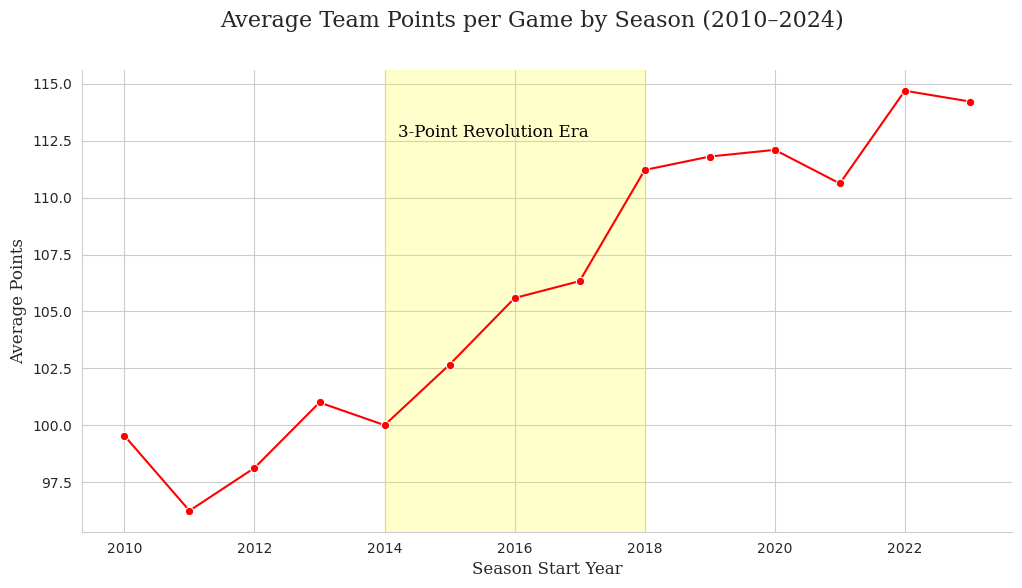

In [7]:
mean_pts_trend = theme_df.groupby("SEASON_START")["PTS"].mean().reset_index()

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Line plot
sns.lineplot(
    data=mean_pts_trend,
    x='SEASON_START',
    y='PTS',
    color='red',
    marker='o'
)

# Highlight region (2014–2018)
plt.axvspan(2014, 2018, color='yellow', alpha=0.2)

# Annotation text
plt.text(
    2014.2, 
    mean_pts_trend["PTS"].max() - 2,
    "3-Point Revolution Era",
    fontsize=12,
    fontfamily='serif',
    color='black'
)

plt.suptitle("Average Team Points per Game by Season (2010–2024)", fontsize=16, fontfamily='serif')
plt.xlabel("Season Start Year", fontsize=12, fontfamily='serif')
plt.ylabel("Average Points", fontsize=12, fontfamily='serif')

sns.despine()

plt.savefig("avg_team_points_per_game.png", dpi=300, bbox_inches='tight')

plt.show()


### Average 3-Point attempts over time 

This plot shows the rise in 3-Point attempts 

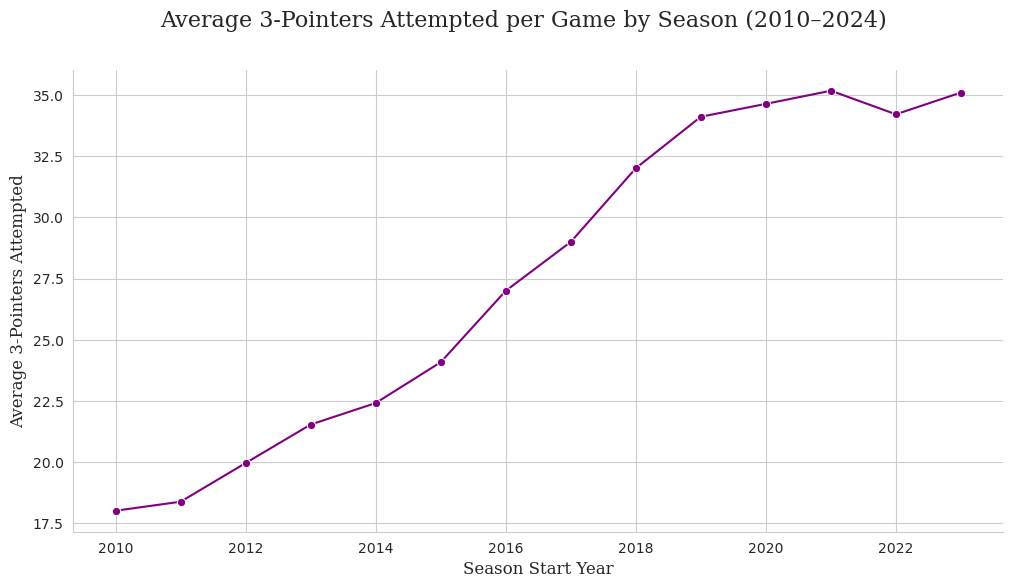

In [8]:
threes_attempted_trend = theme_df.groupby("SEASON_START")["FG3A"].mean().reset_index()

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(data=threes_attempted_trend,
            x = 'SEASON_START',
            y = 'FG3A',
            color='purple',
            marker='o'
            )



plt.suptitle("Average 3-Pointers Attempted per Game by Season (2010–2024)",fontsize=16, fontfamily='serif')
plt.xlabel("Season Start Year",fontsize=12,fontfamily='serif')
plt.ylabel("Average 3-Pointers Attempted",fontsize=12,fontfamily='serif')
sns.despine()

plt.savefig("avg_3pters_per_game.png", dpi=300, bbox_inches='tight')

plt.show()

### Average 3-Point Percentage Over Time

This plot shows whether teams have become better at shooting 3-Point percentages over time.

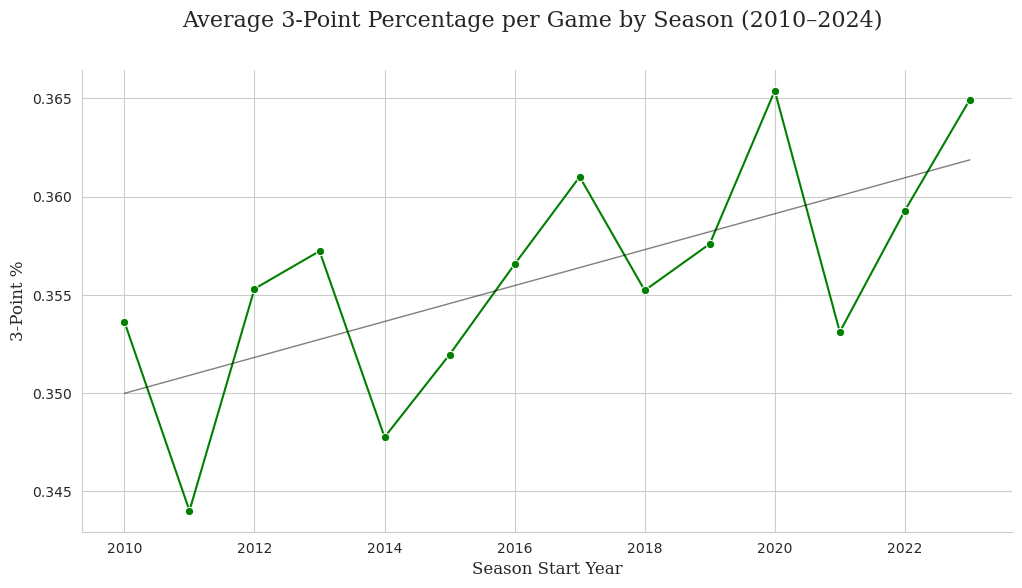

In [9]:
threes_shooting_pct = theme_df.groupby("SEASON_START")["FG3_PCT"].mean().reset_index()

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

sns.lineplot(data=threes_shooting_pct,
            x = 'SEASON_START',
            y = 'FG3_PCT',
            color='green',
            marker='o'
            )

sns.regplot(
    data=threes_shooting_pct,
    x='SEASON_START',
    y = 'FG3_PCT',
    scatter=False,
    line_kws={"linewidth": 1, "alpha": 0.5},
    label='Trend Line',
    color='black',
    ci=None
)

plt.suptitle("Average 3-Point Percentage per Game by Season (2010–2024)",fontsize=16, fontfamily='serif')
plt.xlabel("Season Start Year",fontsize=12,fontfamily='serif')
plt.ylabel("3-Point %",fontsize=12,fontfamily='serif')
sns.despine()
plt.show()

### Average Field Goal Percentage Over Time

This plot shows how teams have changed in terms of being successful at field goals

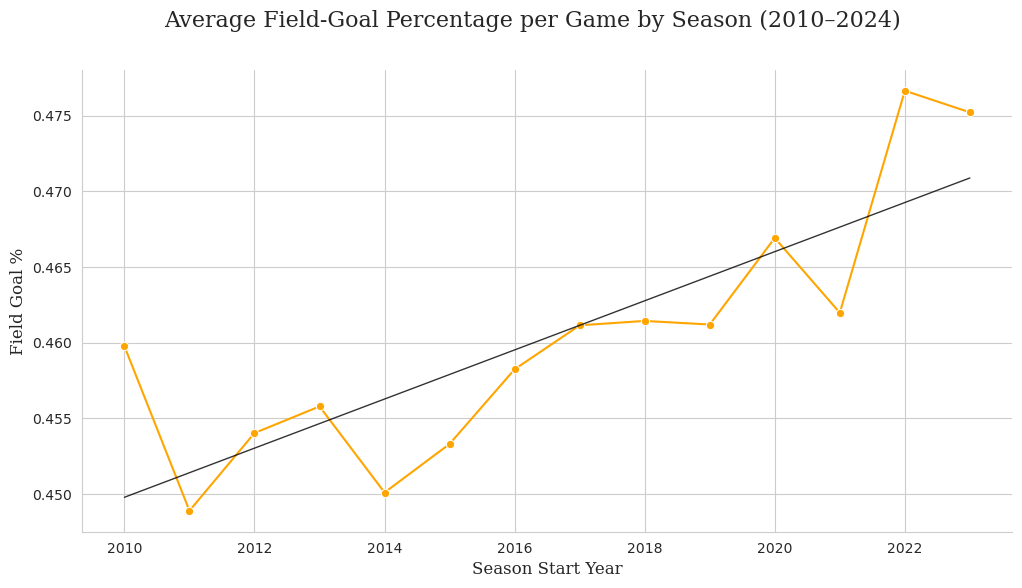

In [10]:
fg_pct_trend = theme_df.groupby("SEASON_START")["FG_PCT"].mean().reset_index()

sns.set_style("whitegrid")
plt.figure(figsize=(12,6))

sns.lineplot(data=fg_pct_trend, 
             x="SEASON_START", 
             y="FG_PCT", 
             marker="o", 
             color="orange")

sns.regplot(
    data=fg_pct_trend,
    x='SEASON_START',
    y = 'FG_PCT',
    scatter=False,
    line_kws={"linewidth": 1, "alpha": 0.8},
    label='Trend Line',
    color='black',
    ci=None
)


plt.suptitle("Average Field-Goal Percentage per Game by Season (2010–2024)",fontsize=16, fontfamily='serif')
plt.xlabel("Season Start Year",fontsize=12,fontfamily='serif')
plt.ylabel("Field Goal %",fontsize=12,fontfamily='serif')
sns.despine()
plt.show()


### Scatterplot and KDE Plot of 3-Pointers Attempted vs Points

The purpose of this plot is to see if teams that attempt more 3-pointers tend to have more points overall

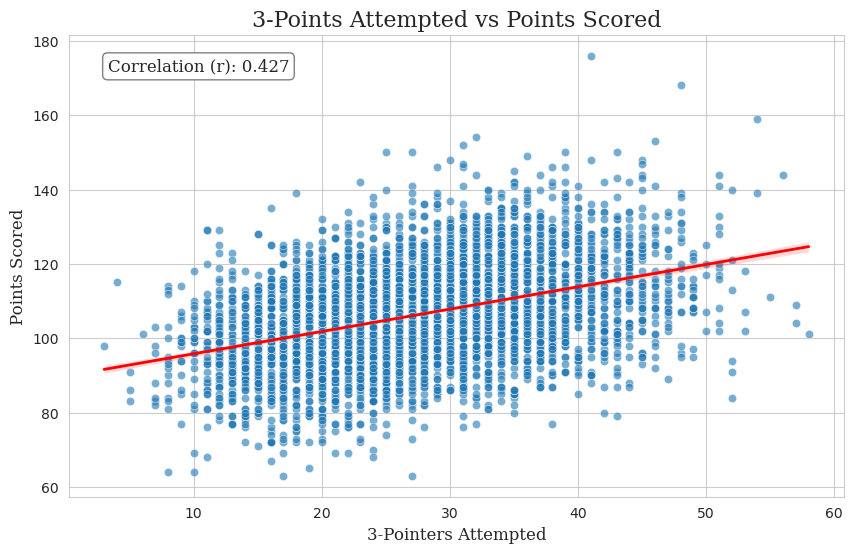

In [11]:
#calculate correlation coeff
df_sample = theme_df.sample(4500)
corr = df['FG3A'].corr(df['PTS'])

plt.figure(figsize=(10,6))
sns.set_style('whitegrid')

sns.scatterplot(data=df_sample,
                x='FG3A',
                y='PTS',
                alpha=0.6,
                
)

# Line of best fit
sns.regplot(
    data=df_sample,
    x='FG3A',
    y='PTS',
    scatter=False,      
    color='red',
    line_kws={'linewidth': 2}
)

plt.title("3-Points Attempted vs Points Scored",fontsize=16, fontfamily='serif')
plt.xlabel("3-Pointers Attempted",fontsize=12,fontfamily='serif')
plt.ylabel("Points Scored",fontsize=12,fontfamily='serif')

plt.text(
    0.05, 0.95,
    f"Correlation (r): {corr:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    fontfamily='serif',
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray")
)

plt.savefig("3pa_pts_scatter.png", dpi=300, bbox_inches='tight')


plt.show()

The moderate positive relationship between 3PA and points aligns with the evolution of NBA offense. As teams have increased their reliance on the 3-point shot, overall scoring has risen as well. The plot illustrates how greater 3-point volume contributes to today’s higher-scoring environment

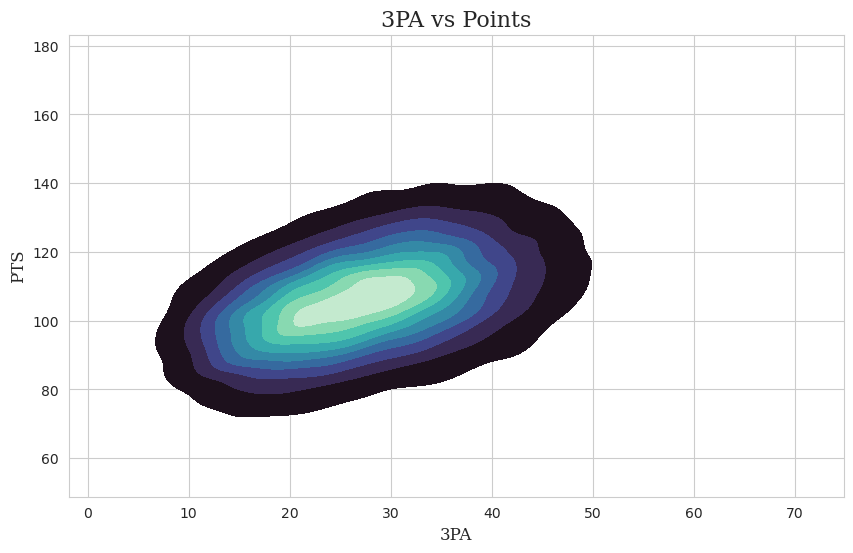

In [12]:
 # KDE plot
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=theme_df,
    x="FG3A",
    y="PTS",
    fill=True,
    cmap="mako"
)
plt.title("3PA vs Points",fontsize=16, fontfamily='serif')
plt.xlabel("3PA",fontsize=12,fontfamily='serif')
plt.ylabel("PTS",fontsize=12,fontfamily='serif')
plt.show()

The KDE shows that NBA teams most frequently score around 100–115 points while attempting 20–35 threes, and that higher 3PA generally corresponds to higher total points, though extreme values are much less common.

### Hexbin to show 3pa vs pts relationship to compare with kde

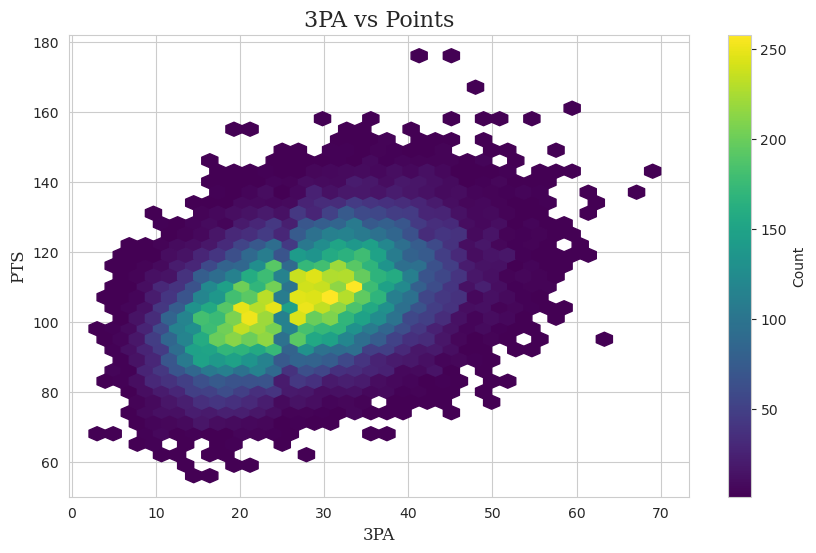

In [13]:
plt.figure(figsize=(10,6))
plt.hexbin(
    theme_df["FG3A"],
    theme_df["PTS"],
    gridsize=35,
    cmap="viridis",
    mincnt=1
)
plt.colorbar(label="Count")
plt.title("3PA vs Points",fontsize=16,fontfamily='serif')
plt.xlabel("3PA",fontsize=12,fontfamily='serif')
plt.ylabel("PTS",fontsize=12,fontfamily='serif')
plt.show()

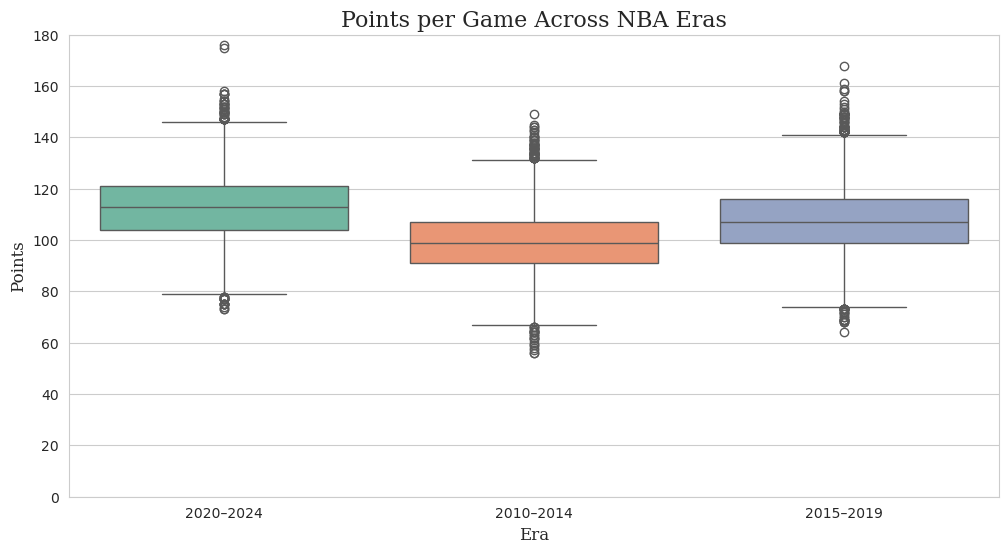

In [14]:
def assign_era(year):
    if year <= 2014:
        return "2010–2014"
    elif year <= 2019:
        return "2015–2019"
    else:
        return "2020–2024"

theme_df["ERA"] = theme_df["SEASON_START"].apply(assign_era)

plt.figure(figsize=(12,6))
sns.boxplot(data=theme_df, x="ERA", y="PTS", palette="Set2")
plt.title("Points per Game Across NBA Eras",fontsize=16,fontfamily='serif')
plt.xlabel("Era",fontsize=12,fontfamily='serif')
plt.ylabel("Points",fontsize=12,fontfamily='serif')
plt.ylim(0,180)
plt.show()


Scoring has increased over time (clear upward trend).

2020–2024 has the highest median points per game, noticeably above the earlier eras.

2015–2019 is in the middle.

2010–2014 shows the lowest overall scoring.

The NBA has continued trending toward faster pace, more spacing, and more three-point shooting, resulting in higher team scoring.

### Histogram of points by era

This histogram shows how NBA scoring distributions have shifted upward over time

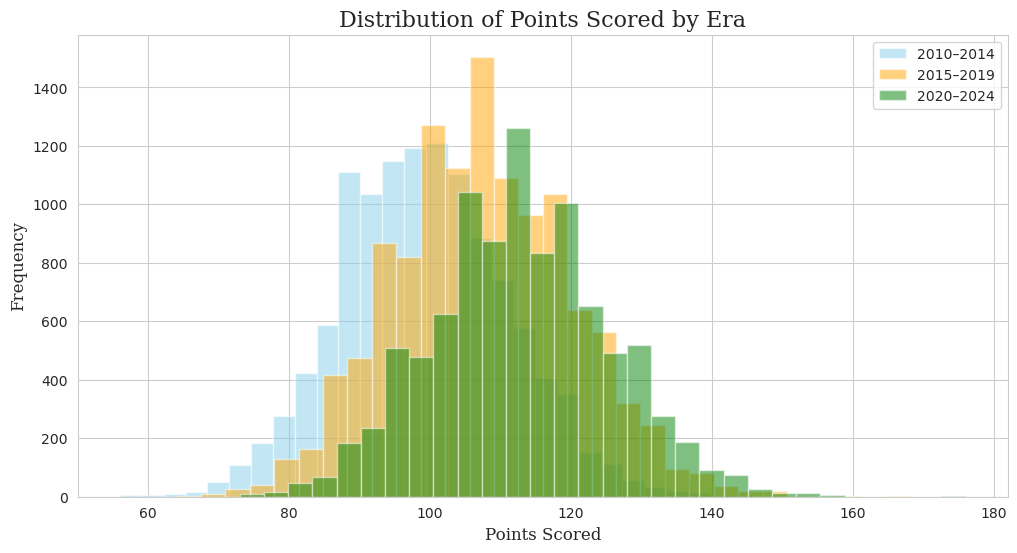

In [15]:
plt.figure(figsize=(12,6))

eras = ["2010–2014", "2015–2019", "2020–2024"]
colors = ["skyblue", "orange", "green"]

for era, color in zip(eras, colors):
    subset = theme_df[theme_df["ERA"] == era]
    plt.hist(
        subset["PTS"],
        bins=30,
        alpha=0.5,
        label=era,
        color=color
    )

plt.title("Distribution of Points Scored by Era",fontsize=16,fontfamily='serif')
plt.xlabel("Points Scored",fontsize=12,fontfamily='serif')
plt.ylabel("Frequency",fontsize=12,fontfamily='serif')
plt.legend()
plt.savefig("histogram_pts_era.png", dpi=300, bbox_inches='tight')

plt.show()


2010–2014 (light blue): Most games fall between 90–105 points, with very few games exceeding 115 points.

2015–2019 (orange): The distribution moves rightward, clustering around 100–115 points, showing an increase in pace and offensive efficiency.

2020–2024 (green): The distribution shifts even further right, with a large portion of games scoring 110–125+ points.

The rightward shift across eras indicates that NBA teams are not only scoring more on average, but the entire scoring environment has transformed.

### Notebook 2 — Summary of Exploratory Findings

The exploratory visualizations consistently show that NBA scoring has increased from 2010 to 2024. Line plots of average points and 3-point attempts, and points per game over time reveal clear upward trends, confirming that teams have gotten more offensive and focused on scoring more and also shoot more threes now than in earlier eras. Density visualizations (KDE, hexbin) show a moderately positive relationship between 3-point attempts and total points. Distribution plots (histogram and KDE by era) demonstrate a rightward shift in the entire scoring distribution, with modern games regularly exceeding 115 points. Together, these findings support the theme that offensive strategy, pace, and the analytics-driven emphasis on the 3-point shot have fundamentally reshaped NBA scoring.